1. FORECAST DE CUSTO

Prever quanto vai se gastar no futuro com base no passado.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/home/tatiane/repositorios/finops-data-cost-monitoring/data/processed/dataset_cost.csv")
df['date'] = pd.to_datetime(df['date'])

# custo diário
daily_cost = df.groupby('date')['total_cost'].sum().reset_index()

In [5]:
# média móvel
# Utilizei média móvel de 7 dias para prever tendência de custo.
daily_cost['rolling_mean'] = daily_cost['total_cost'].rolling(window=7).mean()

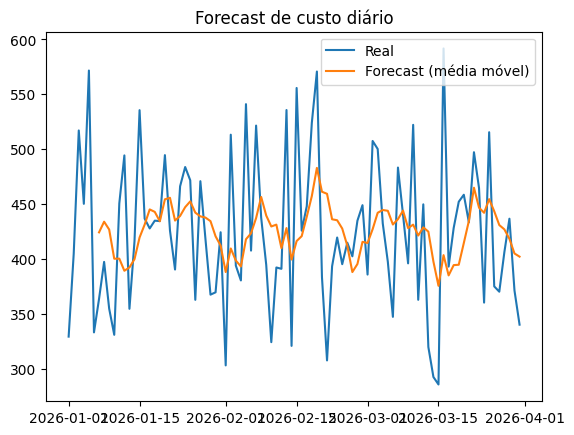

In [6]:
# Visualização
plt.figure()

plt.plot(daily_cost['date'], daily_cost['total_cost'], label='Real')
plt.plot(daily_cost['date'], daily_cost['rolling_mean'], label='Forecast (média móvel)')

plt.legend()
plt.title("Forecast de custo diário")
plt.show()

2. BUDGET VS REALIZADO

Comparar quanto deveria gastar vs quanto realmente gastou

In [17]:
# Definição de orçamento
MONTHLY_BUDGET = 30000  

df['month'] = df['date'].dt.to_period('M')

monthly_cost = df.groupby('month')['total_cost'].sum().reset_index()
monthly_cost['budget'] = MONTHLY_BUDGET

In [19]:
# Comparação
monthly_cost['difference'] = monthly_cost['total_cost'] - monthly_cost['budget']
monthly_cost['percent'] = (monthly_cost['total_cost'] / monthly_cost['budget']) * 100

monthly_cost

,month,total_cost,budget,difference,percent
0,2026-01,13181.297900,30000,-16818.702100,43.937660
1,2026-02,11979.548325,30000,-18020.451675,39.931828
2,2026-03,13014.182525,30000,-16985.817475,43.380608


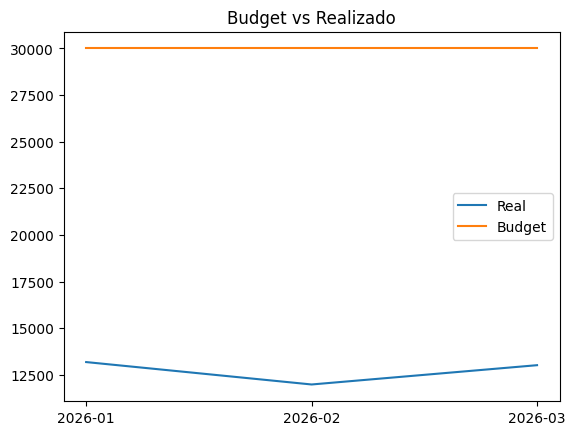

In [20]:
# Visualização
plt.figure()

plt.plot(monthly_cost['month'].astype(str), monthly_cost['total_cost'], label='Real')
plt.plot(monthly_cost['month'].astype(str), monthly_cost['budget'], label='Budget')

plt.legend()
plt.title("Budget vs Realizado")
plt.show()

3. ALERTAS AUTOMÁTICOS

Criar regras que avisam quando algo está errado

In [13]:
# 1. Alerta de estouro de budget
monthly_cost['alert_budget'] = monthly_cost['total_cost'] > monthly_cost['budget']

In [14]:
# 2. Alerta de custo alto por dia
threshold = daily_cost['total_cost'].mean() * 1.5
daily_cost['alert_spike'] = daily_cost['total_cost'] > threshold

In [15]:
# 3. Alerta de usuário caro
user_cost = df.groupby('user_id')['total_cost'].sum()
high_cost_users = user_cost[user_cost > user_cost.mean() * 2]